In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install langchain-community langchain-huggingface faiss-cpu pypdf lightsim2grid grid2op -q
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
!pip install torch==2.10.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128 -q
!pip install https://github.com/state-spaces/mamba/releases/download/v2.3.2.post1/mamba_ssm-2.3.2.post1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl --force-reinstall --no-deps -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.2/382.2 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.6/18.6 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.

/tmp/ipykernel_871/428677037.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFDirectoryLoader


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 43.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 916.9/916.9 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 47.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuda-python 12.9.7 requires cuda-bindings~=12.9.7, but you have cuda-bindings 12.9.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 5.0 MB/s eta 0:00:00


In [4]:
!pip install https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.6.1.post4/causal_conv1d-1.6.1+cu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.6/287.6 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 15.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mamba-ssm 2.3.2.post1 requires apache-tvm-ffi<=0.1.9, which is not installed.
mamba-ssm 2.3.2.post1 requires quack-kernels>=0.3.4, which is not installed.
mamba-ssm 2.3.2.post1 requires tilelang==0.1.8, which is not installed.


In [5]:
from mamba_ssm import Mamba2
import torch
import gc
# 1. Initialize Mamba2 to CUDA (Notice: is_mimo=False is not needed for Mamba2)
print("Initializing Mamba2...")
model = Mamba2(d_model=128, d_state=32, headdim=64).cuda()
# 2. Forge a dummy tensor [Batch, Sequence_Length, D_Model]
x = torch.randn(2, 128, 128).cuda()
# 3. Forward Pass
y = model(x)
print(f"✅ Mamba2 working beautifully! Output shape: {y.shape}")
# 4. Clean up the VRAM!
del model, x, y
gc.collect()
torch.cuda.empty_cache()

Initializing Mamba2...
✅ Mamba2 working beautifully! Output shape: torch.Size([2, 128, 128])


In [6]:
import os
import json
import re
import time
import pickle
import random
import collections
from typing import Tuple, Any, Dict, List

import numpy as np
import torch
import grid2op
from lightsim2grid import LightSimBackend

In [7]:
!unzip -q /content/drive/MyDrive/Grid2Op_Data/grid2op.zip -d /content/grid2op

In [8]:
env = grid2op.make("/content/grid2op/root/data_grid2op/l2rpn_wcci_2020")
gen_pmax = env.gen_pmax
solar_mask = np.array([t == 'solar' for t in env.gen_type])
wind_mask  = np.array([t == 'wind'  for t in env.gen_type])

In [ ]:
def _extract_seq_fn(obs):
    """Tier 1: Dense array for the sequence model."""
    return np.concatenate([
        obs.rho,                                    # (N_LINE,)
        obs.v_or,                                   # (N_LINE,)
        obs.v_ex,                                   # (N_LINE,)
        obs.p_or,                                   # (N_LINE,)
        obs.q_or,                                   # (N_LINE,)
        obs.line_status.astype(np.float32),         # (N_LINE,)
        obs.timestep_overflow.astype(np.float32),   # (N_LINE,)
        obs.load_p,                                 # (N_LOAD,)
        obs.gen_p,                                  # (N_GEN,)
        obs.topo_vect.astype(np.float32),           # (DIM_TOPO,)
    ]).astype(np.float32)


def _extract_tab_fn(obs):
    """Tier 2: Scalar summaries for XGBoost."""
    # Weather proxies
    solar_total_cap = gen_pmax[solar_mask].sum()
    wind_total_cap  = gen_pmax[wind_mask].sum()
    solar_cf = obs.gen_p[solar_mask].sum() / (solar_total_cap + 1e-8) if solar_mask.any() else 0.0
    wind_cf  = obs.gen_p[wind_mask].sum()  / (wind_total_cap  + 1e-8) if wind_mask.any() else 0.0

    all_v = np.concatenate([obs.v_or, obs.v_ex])

    def safe_min(arr, default=-1.0):
        return arr.min() if arr.size > 0 else default

    return np.array([
        # Weather proxies
        solar_cf,
        wind_cf,
        # Grid stress
        obs.rho.max(),
        obs.rho.mean(),
        obs.rho.std(),
        (obs.rho >= 0.85).sum(),                          # n_overloaded
        (obs.rho >= 0.95).sum(),                          # n_critical
        all_v.min(),                                      # min_voltage
        all_v.mean(),                                     # mean_voltage
        (~obs.line_status).sum(),                         # n_disconnected
        # Operational state
        (obs.time_before_cooldown_line > 0).sum(),        # n_lines_cooldown
        obs.time_before_cooldown_line.max() if obs.time_before_cooldown_line.size > 0 else 0.0,
        (obs.time_before_cooldown_sub > 0).sum(),         # n_subs_cooldown
        (obs.time_next_maintenance == 0).sum(),           # n_lines_in_maintenance
        safe_min(obs.time_since_last_attack) if hasattr(obs, 'time_since_last_attack') else -1,
        # Storage
        obs.storage_charge.mean() if obs.storage_charge is not None and obs.storage_charge.size > 0 else 0.0,
        obs.storage_power.sum()   if obs.storage_power is not None and obs.storage_power.size > 0 else 0.0,
        # Load/gen balance
        obs.load_p.sum(),
        obs.load_p.std(),
        obs.load_p.max() / (obs.load_p.mean() + 1e-8),
        obs.gen_p.sum(),
        obs.load_p.sum() / (obs.gen_p.sum() + 1e-8),     # load_gen_ratio
        # Temporal
        np.sin(2 * np.pi * obs.hour_of_day / 24),
        np.cos(2 * np.pi * obs.hour_of_day / 24),
        obs.day_of_week,
        obs.month,
    ], dtype=np.float32)


TABULAR_NAMES = [
    'solar_cf', 'wind_cf',
    'max_rho', 'mean_rho', 'std_rho', 'n_overloaded', 'n_critical',
    'min_voltage', 'mean_voltage', 'n_disconnected',
    'n_lines_cooldown', 'max_cooldown', 'n_subs_cooldown',
    'n_lines_maintenance', 'time_since_attack',
    'storage_soc_mean', 'storage_power_total',
    'total_load', 'load_std', 'peak_load_ratio',
    'total_gen', 'load_gen_ratio',
    'hour_sin', 'hour_cos', 'day_of_week', 'month',
]

In [ ]:
import torch.nn as nn
class _GridRiskMamba(nn.Module):
    def __init__(self, seq_dim, n_line, n_load, n_gen, d_model=128, n_layers=4, d_state=32):
        super().__init__()
        self.n_line = n_line
        self.input_proj = nn.Sequential(nn.LayerNorm(seq_dim), nn.Linear(seq_dim, d_model), nn.LayerNorm(d_model))

        use_mamba = False
        try:
            from mamba_ssm import Mamba2
            if torch.cuda.is_available():
                use_mamba = True
        except Exception:
            use_mamba = False
        self.backbone = nn.ModuleList([Mamba2(d_model=128, d_state=32, headdim=64) for _ in range(n_layers)])
        print("Using Mamba2 backbone (CUDA).")

        self.norm = nn.LayerNorm(d_model)
        self.class_head = nn.Sequential(nn.Linear(d_model, 128), nn.GELU(), nn.Dropout(0.2), nn.Linear(128, n_line * 2 + 1))
        self.physics_head = nn.Sequential(nn.Linear(d_model, 128), nn.GELU(), nn.Linear(128, n_line + 2 + n_line))
        self.d_model = d_model
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4, dim_feedforward=256, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        for layer in self.backbone:
            x = layer(x)
        x = self.norm(x)
        embedding = x[:, -1, :]
        logits = self.class_head(embedding)
        physics_pred = self.physics_head(embedding)
        return logits, embedding, physics_pred

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/Grid2Op_Data/Grid/TF/"
META_PATH = os.path.join("/content/drive/MyDrive/Grid2Op_Data/Grid/Grid Model/", "meta.json")
if not os.path.exists(META_PATH):
    raise SystemExit("meta.json not found in ./grid_models. Run Grid_clean.py first.")

with open(META_PATH) as fh:
    meta = json.load(fh)

# FAISS Database Preparation (Done separately)

In [ ]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
'''
The documents used to feed the RAG Agent are:
- NERC EOP-011
- NERC TOP-001
- Grid2Op Learning to Run a Power Network Challenge
'''
loader = PyPDFDirectoryLoader("./grid_manuals/")
documents = loader.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_db = FAISS.from_documents(chunks, embeddings)
vector_db.save_local("./faiss_grid_index")

In [ ]:
FEATURE_SLICES = {k: tuple(v) for k, v in meta['feature_slices'].items()}
SEQ_DIM = meta['seq_dim']
N_LINE = meta['n_line']
N_LOAD = meta['n_load']
N_GEN = meta['n_gen']
PRED_HORIZON = meta.get('pred_horizon', 4)

_llm_client = None
_llm_kind = None
_api_key = "DEFAULT_OR_PLACEHOLDER"
_llm_client = True

FAISS_INDEX_PATH = "/content/drive/MyDrive/faiss_grid_index"


SYSTEM_PROMPT = """
You are a conservative Power Grid RAG Agent serving as the final Safety Filter.
Evaluate the provided JSON containing a list of Top-K heuristic candidate actions.
Select the SAFEST action index (0-N) that complies with NERC protocols.

OUTPUT FORMAT:
{
  "selected_action_index": <int>,
  "rationale": "<Reason citing NERC protocols and projected impact on physical load>"
}
"""

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

def predict_on_new_data(X_new_raw, trained_models_list):
    """Predicts calibrated probabilities on a brand new dataset."""
    print(f"Executing chain predictions on {X_new_raw.shape[0]} new rows...")
    X_curr = X_new_raw.copy()
    preds_list = []

    for idx, model in enumerate(trained_models_list):
        try:
            prob = model.predict_proba(X_curr)[:, 1]
        except Exception:
            prob = np.zeros(X_curr.shape[0])

        preds_list.append(prob)

        # Original clean execution precisely as you wrote it
        binary_pred = model.predict(X_curr).reshape(-1, 1)
        X_curr = np.hstack([X_curr, binary_pred])

    return np.vstack(preds_list).T


print("Loading embeddings...")
X_train_xgb = np.load(os.path.join(MODEL_DIR, "X_train.npy"))
y_train_xgb = np.load(os.path.join(MODEL_DIR, "y_train.npy"))
X_test_xgb  = np.load(os.path.join(MODEL_DIR, "X_test.npy"))
y_test_xgb  = np.load(os.path.join(MODEL_DIR, "y_test.npy"))


Loading embeddings...


In [ ]:
print("Training Manual Custom Classifier Chain (~60 seconds)...")
# While I used a Classifier Chain instead of a Calibrated Classifier CV, the macro AP score remains conserved.
params = {'n_estimators': 150, 'max_depth': 4, 'objective': 'binary:logistic', 'tree_method': 'hist', 'device': 'cuda'}
n_targets = y_train_xgb.shape[1]
models = []

X_train_curr = X_train_xgb.copy()

for i in range(n_targets):
    y_col = y_train_xgb[:, i]

    if y_col.sum() >= 3:
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        model = CalibratedClassifierCV(XGBClassifier(**params), method='sigmoid', cv=skf)
    else:
        model = XGBClassifier(**params)

    model.fit(X_train_curr, y_col)
    models.append(model)

    train_binary = model.predict(X_train_curr).reshape(-1, 1)
    X_train_curr = np.hstack([X_train_curr, train_binary])

Training Manual Custom Classifier Chain (~60 seconds)...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [18:52:41] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Executing chain predictions on 9988 new rows...


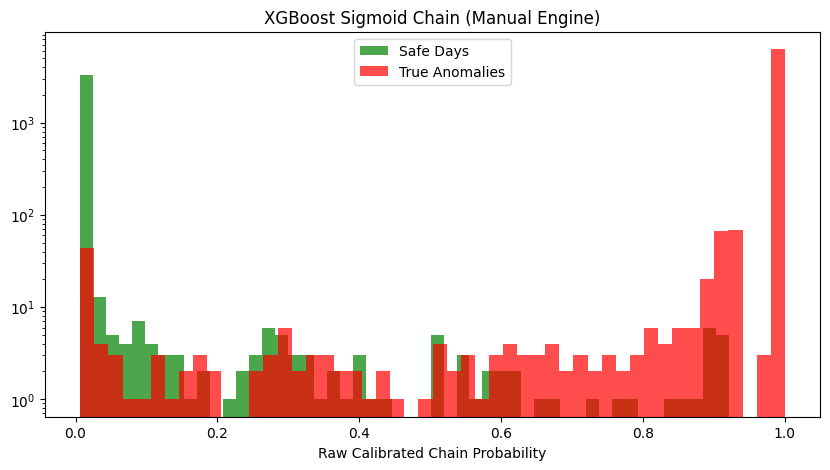

In [ ]:
preds = predict_on_new_data(X_test_xgb, models)

max_probs = np.max(preds, axis=1)
has_anomaly = y_test_xgb.sum(axis=1) > 0

plt.figure(figsize=(10, 5))
plt.hist(max_probs[~has_anomaly], bins=50, alpha=0.7, color='green', label='Safe Days', log=True)
plt.hist(max_probs[has_anomaly], bins=50, alpha=0.7, color='red', label='True Anomalies', log=True)
plt.title(f"XGBoost Sigmoid Chain (Manual Engine)")
plt.xlabel("Raw Calibrated Chain Probability")
plt.legend()
plt.show()

In [ ]:
def _safe_int(x, default=None):
    try:
        if x is None:
            return default
        if isinstance(x, (np.floating, np.integer)):
            if np.isnan(x):
                return default
        return int(x)
    except Exception:
        return default

def _safe_float(x, default=0.0):
    try:
        if x is None:
            return default
        if isinstance(x, (np.floating,)) and np.isnan(x):
            return default
        return float(x)
    except Exception:
        return default

def predict_on_new_data(X_new_raw, trained_models_list):
    """Predicts EXACT final binary classes."""
    X_curr = X_new_raw.copy()
    preds_list = []

    for idx, model in enumerate(trained_models_list):
        try:
            binary_pred = model.predict(X_curr)
        except Exception:
            binary_pred = np.zeros(X_curr.shape[0])

        preds_list.append(binary_pred)
        X_curr = np.hstack([X_curr, binary_pred.reshape(-1, 1)])

    return np.vstack(preds_list).T

def _sanitize_for_json(obj):
    """Recursively convert numpy types to Python scalars for json.dumps."""
    if isinstance(obj, dict):
        return {k: _sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_sanitize_for_json(v) for v in obj]
    if isinstance(obj, tuple):
        return tuple(_sanitize_for_json(v) for v in obj)
    if isinstance(obj, np.ndarray):
        return _sanitize_for_json(obj.tolist())
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

class ProductionCopilot:
    def __init__(self, api_key: str = None, custom_xgb_chain=None):
        self.env = grid2op.make("/content/grid2op/root/data_grid2op/l2rpn_wcci_2020", backend=LightSimBackend())
        self.window_size = 128
        self.obs_buffer = collections.deque(maxlen=self.window_size)
        self.organic_steps = 0  # 🚨 Tracks how much organic vs padded data exists
        self.vector_db = None

        if FAISS_INDEX_PATH:
            try:
                from langchain_community.vectorstores import FAISS
                from langchain_huggingface import HuggingFaceEmbeddings
                embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
                self.vector_db = FAISS.load_local(FAISS_INDEX_PATH, embeddings, allow_dangerous_deserialization=True)
                print("FAISS DB loaded.")
            except Exception as e:
                print("FAISS load failed:", e)
                self.vector_db = None

        # load custom ML ensemble and neural model
        self.use_real_models = False
        self.xgb_chain = custom_xgb_chain
        try:
            state = torch.load(os.path.join(MODEL_DIR, "best_model.pt"), map_location='cpu', weights_only=False)
            if _GridRiskMamba is not None:
                self.mamba = _GridRiskMamba(seq_dim=SEQ_DIM, n_line=N_LINE, n_load=N_LOAD, n_gen=N_GEN, d_model=128, n_layers=4, d_state=32)
                self.mamba.load_state_dict(state['model_state'])
                self.mamba.eval()
                if torch.cuda.is_available():
                    self.mamba.to("cuda")
                self.use_real_models = True
                print("Loaded PyTorch models securely.")
            else:
                print("GridRiskMamba not available; falling back.")
        except Exception as e:
            print("Model loading failed; falling back to heuristics. Error:", e)
            self.use_real_models = False

        self.llm = None
        if _llm_client and api_key:
            try:
                from google import genai
                self.llm = genai.Client(api_key=api_key)
                print("LLM client securely loaded for Gemini 2.5 Flash.")
            except Exception as e:
                print("LLM init failed:", e)


    def detect_risk(self, obs, mutate_buffer: bool = True) -> Tuple[float, np.ndarray]:
        """Run the model stack to compute a scalar risk and per-line probabilities.
        If mutate_buffer=False, the internal obs history is not appended (safe for sandbox)."""
        try:
            if _extract_seq_fn:
                seq = _extract_seq_fn(obs)
            else:
                seq = np.concatenate([obs.rho, obs.v_or, obs.v_ex, obs.p_or, obs.q_or,
                                      obs.line_status.astype(np.float32),
                                      obs.timestep_overflow.astype(np.float32),
                                      obs.load_p, obs.gen_p, obs.topo_vect.astype(np.float32)]).astype(np.float32)
        except Exception as e:
            print("Sequence extraction failed:", e)
            # fallback: conservative heuristic
            line_probs = np.clip(getattr(obs, 'rho', np.zeros(N_LINE)) + np.random.normal(0, 0.05, size=N_LINE), 0, 1)
            return float(1.0 if np.max(line_probs) > 0.90 else 0.0), line_probs

        if mutate_buffer:
            self.organic_steps += 1 
            self.obs_buffer.append(seq)
            while len(self.obs_buffer) < self.window_size:
                self.obs_buffer.append(seq)

        if mutate_buffer:
            seq_matrix = np.array(self.obs_buffer)
        else:
            if len(self.obs_buffer) == 0:
                seq_matrix = np.tile(seq, (self.window_size, 1))
            else:
                seq_matrix = np.array(list(self.obs_buffer))
                if seq_matrix.shape[0] < self.window_size:
                    pad = np.tile(seq, (self.window_size - seq_matrix.shape[0], 1))
                    seq_matrix = np.concatenate([pad, seq_matrix], axis=0)
        # Training applied per-window z-score + clip[-5,5]. Without this, Mamba receives
        # raw physical values (voltages in kV, power in MW) vs. its trained normalized space.
        # Effect without fix: sigmoid(logits) collapses to ~0.5 → near-zero anomaly counts.
        seq_matrix = seq_matrix.copy().astype(np.float32)
        mean_scale = seq_matrix.mean(axis=0, keepdims=True)
        std_scale  = seq_matrix.std(axis=0,  keepdims=True) + 1e-8
        seq_matrix = (seq_matrix - mean_scale) / std_scale
        seq_matrix = np.clip(seq_matrix, -5.0, 5.0)
        seq_matrix = np.nan_to_num(seq_matrix, nan=0.0, posinf=5.0, neginf=-5.0)

        try:
            if self.use_real_models:
                seq_tensor = torch.tensor(seq_matrix, dtype=torch.float32).unsqueeze(0)
                if torch.cuda.is_available():
                    seq_tensor = seq_tensor.to("cuda")
                with torch.no_grad():
                    logits, emb, _ = self.mamba(seq_tensor)
                # Mamba's classification head is intentionally ignored at inference.
                # Its sole purpose during training was to supervise the embedding space.
                # XGB is the actual risk classifier, it operates on the Mamba state vector.
                    emb_np = emb.cpu().numpy() if isinstance(emb, torch.Tensor) else np.zeros((1, 128))

                    if _extract_tab_fn:
                      tab = _extract_tab_fn(obs).reshape(1, -1)
                    else:
                       tab = np.zeros((1, 26), dtype=np.float32)

                    xgb_features = np.concatenate([emb_np, tab], axis=1)

                    try:
                       if self.xgb_chain is not None and self.organic_steps >= self.window_size:
                            preds_xgb_binary = predict_on_new_data(xgb_features, self.xgb_chain)
                            xgb_anomaly_count = float(np.sum(preds_xgb_binary))
                       else:
                           xgb_anomaly_count = 0.0
                    except Exception:
                       xgb_anomaly_count = 0.0

                    # Physics safety net: guaranteed backstop regardless of ML output.
                    physics_scalar = float((obs.rho >= 0.75).sum())
                    # Warning threshold (0.75): wakes the agent to assess the grid.
                    # Action threshold (0.90): inside build_heuristic_actions, only lines
                   # above 0.90 rho become intervention candidates. Agent safely no-ops if assessment finds no confirmed critical lines.
                    line_probs = (obs.rho >= 0.75).astype(float)

                    scalar = max(xgb_anomaly_count, physics_scalar)
                    return scalar, line_probs
        except Exception as e:
            print("ML inference error:", e)

        # fallback heuristic (Strictly Boolean)
        line_probs = np.clip(obs.rho + np.random.normal(0, 0.05, size=N_LINE), 0, 1)
        return float(1.0 if np.max(line_probs) > 0.90 else 0.0), line_probs

    def build_enterprise_scada_payload(self, obs, line_probs, scalar, prior_failures=None, warn_th=0.70, crit_th=0.85) -> str:
        n_line = getattr(self.env, "n_line", None)
        if n_line is None:
            raise ValueError("self.env.n_line missing")
        line_status = list(getattr(obs, "line_status", []))
        rho_arr = list(getattr(obs, "rho", []))
        or_sub = list(getattr(obs, "line_or_to_subid", []))
        ex_sub = list(getattr(obs, "line_ex_to_subid", []))
        line_probs = list(line_probs)

        # Build substation -> lines map for fast neighbor lookup (O(n) instead of O(n^2))
        sub_to_lines = collections.defaultdict(list)
        for l in range(n_line):
            s_or = _safe_int(or_sub[l])
            s_ex = _safe_int(ex_sub[l])
            if s_or is not None:
                sub_to_lines[s_or].append(l)
            if s_ex is not None and s_ex != s_or:
                sub_to_lines[s_ex].append(l)

        # Base payload
        try:
            total_mw = float(getattr(obs, "load_p", np.array([])).sum())
        except Exception:
            total_mw = 0.0

        payload = {
            "metrics": {"total_mw": round(total_mw, 3), "sys_risk": round(_safe_float(scalar), 3)},
            "offline_lines": [],
            "critical_lines": [],
            "warning_lines": [],
            "generators": []
        }

        # 1) Offline lines
        for l_id in range(n_line):
            if not bool(line_status[l_id]):
                payload["offline_lines"].append(int(l_id))

        # 2) Line risk + neighbors
        for l_id in range(n_line):
            rho = _safe_float(rho_arr[l_id], default=0.0)

            if rho > warn_th:
                sub_or = _safe_int(or_sub[l_id])
                sub_ex = _safe_int(ex_sub[l_id])

                neighbors_set = set()
                if sub_or is not None:
                    neighbors_set.update(sub_to_lines.get(sub_or, []))
                if sub_ex is not None:
                    neighbors_set.update(sub_to_lines.get(sub_ex, []))
                neighbors_set.discard(l_id)
                neighbors = sorted(neighbors_set)

                line_data = {
                    "id": int(l_id),
                    "capacity_rho": round(rho, 3),
                    "substations": (sub_or, sub_ex),
                    "neighboring_lines": neighbors
                }

                if rho > crit_th:
                    payload["critical_lines"].append(line_data)
                else:
                    payload["warning_lines"].append(line_data)

        # 3) Generators (sorted by current output, descending)
        gen_p = np.asarray(getattr(obs, "gen_p", np.array([])), dtype=float)
        if gen_p.size:
            top_gens = np.argsort(-gen_p)
            gen_to_sub = list(getattr(obs, "gen_to_subid", []))
            gen_pmax = list(getattr(obs, "gen_pmax", []))
            gen_ramp = list(getattr(obs, "gen_max_ramp_up", []))
            for g_id in top_gens:
                payload["generators"].append({
                    "id": int(g_id),
                    "grid_location_substation": _safe_int(gen_to_sub[g_id]),
                    "current_mw": round(_safe_float(gen_p[g_id]), 1),
                    "max_mw": round(_safe_float(gen_pmax[g_id] if g_id < len(gen_pmax) else None), 1),
                    "ramp_mw_per_step": round(_safe_float(gen_ramp[g_id] if g_id < len(gen_ramp) else None), 1)
                })

        if prior_failures:
            payload["prior_failures"] = _sanitize_for_json(prior_failures)

        payload["diagnostics"] = {
            "n_lines": int(n_line),
            "n_offline": len(payload["offline_lines"]),
            "n_critical": len(payload["critical_lines"]),
            "n_warning": len(payload["warning_lines"])
        }

        payload = _sanitize_for_json(payload)
        return json.dumps(payload, indent=2)

    def retrieve_nerc_protocols(self, anomaly_summary: str) -> str:
        if not self.vector_db:
            return "NERC TOP-001: [NO DOCS LOADED] Under N-1 contingency, relieve bottlenecks via topological intervention or localized ramp-down within 15 minutes."
        try:
            docs = self.vector_db.similarity_search(f"Resolve: {anomaly_summary}", k=2)
            return "\n".join([f"DOC{i+1}:{d.page_content}" for i,d in enumerate(docs)])
        except Exception as e:
            print("RAG retrieval error:", e)
            return "NERC PROTOCOL RETRIEVAL FAILED."

    def ask_llm(self, json_snapshot: str, nerc_docs: str) -> Dict[str, Any]:
        prompt = f"{SYSTEM_PROMPT}\n\n[RETRIEVED NERC PROTOCOLS]:\n{nerc_docs}\n\n[INPUT_SNAPSHOT]:\n{json_snapshot}"
        if not self.llm:
            return {"selected_action_index": 0, "rationale": "LLM not configured; safe default."}
        try:
            resp_obj = self.llm.models.generate_content(model='gemini-3.5-flash-lite', contents=prompt)
            resp = resp_obj.text

            match = re.search(r'\{.*\}', resp, re.DOTALL)
            if match:
                return json.loads(match.group(0))
            return {"selected_action_index": 0, "rationale": "LLM failed to return JSON."}
        except Exception as e:
            print("LLM call failed:", e)
            return {"selected_action_index": 0, "rationale": f"LLM error: {e}"}

    def convert_to_action(self, llm_dict: Dict[str, Any], obs) -> Any:
        try:
            a_type = llm_dict.get('action_type', 'no_op')
            if a_type == 'open_line':
                return self.env.action_space({"set_line_status": [(int(llm_dict['target_id']), -1)]})
            if a_type == 'close_line':
                return self.env.action_space({"set_line_status": [(int(llm_dict['target_id']), 1)]})
            if a_type == 'redispatch_down':
                mag = abs(float(llm_dict.get('magnitude_mw', -50.0)))
                gen_id = int(llm_dict['target_id'])
                avail_down = float(obs.gen_p[gen_id] - obs.gen_pmin[gen_id])
                clamped = min(mag, max(0.0, avail_down))
                if clamped > 0:
                    return self.env.action_space({"redispatch": [(gen_id, -clamped)]})
                return self.env.action_space()
            if a_type == 'no_op': return self.env.action_space()
        except Exception as e:
            print("convert_to_action error:", e)
        return self.env.action_space()

    def run_sandbox_verifier(self, obs, baseline_scalar, action) -> Tuple[bool, float, str]:
        """PHYSICAL VALIDATION: Multi-step rollout to prevent N-1 delayed cascading crashes."""
        try:
            # 1-step physical Sandbox Rollout (simulating multiple steps requires explicit future chronics loading which natively breaks Grid2Op)
            sim_obs, _, done, info = obs.simulate(action)
            if done or info.get('exception'):
                return False, -999.0, "Simulator flagged immediate failure."
        except Exception as e:
            return False, -999.0, f"Simulator error: {e}"

        # Because the ML Models are now strictly Boolean (0 or 1), they cannot measure gradual improvement.
        # The Sandbox dynamically tracks both Thermal Overloads (rho) AND Voltage Collapses (v_or).
        def get_physics_penalty(o):
            return float(np.max(o.rho)) + float(np.max(np.abs(1.0 - o.v_or)) * 2)

        baseline_penalty = get_physics_penalty(obs)
        post_penalty = get_physics_penalty(sim_obs)

        delta = baseline_penalty - post_penalty
        if delta <= 0:
            return False, delta, f"Rejected by Sandbox: Zero physical improvement (Delta {delta:.4f})"
        return True, delta, "Verified stable: Physical metrics improved!"

    def build_heuristic_actions(self, obs, critical_lines) -> List[Dict]:
        """ML proposes Top-K actions heuristically constraints; LLM merely ranks them."""
        candidates = [{"action_type": "no_op", "description": "Do nothing (Safe default)"}]

        # Heuristic 1: Attempt to trip the most overloaded line if it's catastrophic
        if critical_lines:
            candidates.append({
                "action_type": "open_line", "target_id": critical_lines[0],
                "description": f"Open Line {critical_lines[0]} to forcefully redistrbute grid power immediately."
            })

        # 🚨 Heuristic 1.5: Graveyard Restoration (Reconnect maliciously unplugged wires!)
        for l_id in range(getattr(obs, "n_line", 59)):
            if not obs.line_status[l_id]:
                candidates.append({
                    "action_type": "close_line",
                    "target_id": int(l_id),
                    "description": f"CRITICAL: Reconnect Offline Line {l_id} to restore baseline grid topology."
                })

        # Heuristic 2: Attempt standard conservative redispatch on the generator doing the most work!
        largest_gen = int(np.argmax(obs.gen_p))

        # You can ONLY redispatch up to the maximum physical ramp limit
        # Do not propose -100MW to a machine that can only shift 2.8MW
        max_ramp = float(obs.gen_max_ramp_down[largest_gen])
        safe_drop_1 = max_ramp * 0.50
        safe_drop_2 = max_ramp * 1.00

        for mw_change in [safe_drop_1, safe_drop_2]:
            if mw_change > 0:
                candidates.append({
                    "action_type": "redispatch_down",
                    "target_id": largest_gen,
                    "magnitude_mw": -abs(mw_change),
                    "description": f"Redispatch Generator {largest_gen} down by {abs(mw_change):.1f} MW"
                })
        return candidates

    def run_autonomous_loop(self, max_steps=200):
        print("\nStarting Autonomous Grid Defense Loop...")
        print("🌱 RUNNING ORGANIC BURN-IN: Spooling 128 physical grid steps to construct pure Mamba memory...")
        obs = self.env.reset()
        post_action_cooldown = 0
        for step in range(max_steps):
            # Normal forward physics step
            obs, reward, done, _ = self.env.step(self.env.action_space())
            if done:
                print("Grid collapsed organically. Resetting time simulation...")
                obs = self.env.reset()

                self.obs_buffer.clear()
                self.organic_steps = 0
                continue

            scalar, line_probs = self.detect_risk(obs, mutate_buffer=True)

            # Keep ML Models asleep while the organic timeline builds!
            if step < 129:
                if step % 25 == 0:
                    print(f"   [Burn-In Spooling] Time Step {step:03d}/128...")
                continue

            # N-3 artificial attack
            if step == 135:
                telemetry["attack_step"] = step
                heaviest_lines = np.argsort(obs.rho)[-3:]
                line_actions = [(int(l_id), -1) for l_id in heaviest_lines]
                print(f"\n⚠️ N-3 Attack! Tripping lines: {[int(l) for l in heaviest_lines]}")
                obs, _, _, _ = self.env.step(self.env.action_space({"set_line_status": line_actions}))
                scalar, line_probs = self.detect_risk(obs, mutate_buffer=True)
                telemetry["scalar"][-1] = scalar
                telemetry["rho_max"][-1] = float(obs.rho.max())
                print(f"[Post-Attack] Scalar: {scalar:.3f} | rho_max: {obs.rho.max():.3f}")
            # Keeps lines offlines for some steps
            if 135 < step <= 155:
                still_offline = [(l_id, -1) for l_id in range(obs.n_line) if not obs.line_status[l_id]]
                if still_offline:
                    obs, _, _, _ = self.env.step(self.env.action_space({"set_line_status": still_offline}))
                scalar, line_probs = self.detect_risk(obs, mutate_buffer=True)
                telemetry["scalar"][-1] = scalar
                telemetry["rho_max"][-1] = float(obs.rho.max())

            print(f"[Step {step:03d}] System Risk: {scalar:.3f}")

            # THE REAL AUTONOMOUS TRIGGER LOGIC (STRICT BOOLEAN ALERT)
            if post_action_cooldown > 0:
                post_action_cooldown -= 1
                print(f"[Step {step:03d}] Post-mitigation cooldown ({post_action_cooldown} steps remaining). Risk: {scalar:.3f}")
                continue

            if scalar >= 0.99:
                print("\n🚨 THREAT DETECTED! Hard binary trip triggered. Waking up Agent Copilot...")
                critical_lines = [int(i) for i in np.argsort(obs.rho)[-3:][::-1] if obs.rho[i] > 0.90]
                candidate_actions = self.build_heuristic_actions(obs, critical_lines)

                failures = []
                mitigated = False
                for attempt in range(1, 4):
                    payload = self.build_enterprise_scada_payload(obs, line_probs, scalar, prior_failures=failures if failures else None)
                    advanced_payload = f"Candidates:\n{json.dumps(candidate_actions, indent=2)}\nGrid State:\n{payload}"

                    crisis_summary = (
                    f"{len(critical_lines)} critical line(s) overloaded (rho>{0.90}): {critical_lines}. "
                    f"Max rho: {max((obs.rho[l] for l in critical_lines), default=0.0):.3f}. "
                    f"Voltage stress: min_v_or={float(obs.v_or.min()):.3f}. "
                    f"Offline lines: {[l for l in range(obs.n_line) if not obs.line_status[l]]}.")
                    docs = self.retrieve_nerc_protocols(crisis_summary)
                    decision = self.ask_llm(advanced_payload, docs)

                    selected_idx = min(max(int(decision.get('selected_action_index', 0)), 0), len(candidate_actions)-1)
                    selected_action = candidate_actions[selected_idx]

                    print(f"ML Proposed {len(candidate_actions)} actions. LLM selected index: [{selected_idx}]")
                    print(f"Rationale: {decision.get('rationale')}")

                    action = self.convert_to_action(selected_action, obs)
                    safe, delta, reason = self.run_sandbox_verifier(obs, scalar, action)

                    if safe:
                        print("✅ Sandbox verified stable. Executing on live physical grid...")
                        obs, _, done, _ = self.env.step(action)

                        # Forcefully append the MITIGATED grid state into Mamba's memory buffer
                        # so PyTorch doesn't develop amnesia about the crisis resolution!
                        post_mitigation_scalar, _ = self.detect_risk(obs, mutate_buffer=True)
                        print(f"✅ Action executed. Grid improving — rho_max: {obs.rho.max():.3f} | Risk Scalar: {post_mitigation_scalar:.3f} ({'still monitoring' if post_mitigation_scalar >= 0.99 else 'stabilized'})")

                        mitigated = True
                        post_action_cooldown = 10
                        # Production would require a post-action cooldown window
                        # before re-triggering to prevent action flooding on a
                        # partially-resolved grid. Fixed at 10 steps for PoC.
                        break
                    else:
                        print(f"❌ Rejected by sandbox rollout: {reason}")
                        failures.append({'proposal': selected_action, 'reason': reason})

                if not mitigated:
                    print("🛑 All Agent Sandboxes failed. Halting Copilot to avoid blind grid destruction.")

                print("-" * 50)

In [ ]:
api_key_to_use = os.environ.get["API_KEY"]
op = ProductionCopilot(api_key=api_key_to_use, custom_xgb_chain=models)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS DB loaded.
Using Mamba2 backbone (CUDA).
Loaded PyTorch models securely.
LLM client securely loaded for Gemini 2.5 Flash.


In [ ]:
# ─── TELEMETRY COLLECTION RUN ───────────────────────────────────────────────
# Re-run the autonomous loop with full per-step logging for visualization.
# Place this cell immediately after your existing run_autonomous_loop call.

import collections as _collections

telemetry = {
    "steps":        [],
    "scalar":       [],
    "rho_max":      [],
    "rho_mean":     [],
    "n_warning":    [],   # lines >= 0.75
    "n_critical":   [],   # lines >= 0.90
    "agent_trigger": [],  # step indices where agent woke up
    "action_executed": [], # step indices where sandbox approved
    "attack_step":  None,
}

class TelemetryMixin:
    """Wraps run_autonomous_loop to collect per-step data without changing logic."""
    def run_autonomous_loop_telemetry(self, max_steps=200):
        print("\nStarting Telemetry Collection Run...")
        print("🌱 BURN-IN: Spooling 128 steps...")
        obs = self.env.reset()
        post_action_cooldown = 0

        for step in range(max_steps):
            obs, reward, done, _ = self.env.step(self.env.action_space())
            if done:
                print("Grid collapsed. Resetting...")
                obs = self.env.reset()
                self.obs_buffer.clear()
                self.organic_steps = 0
                continue

            scalar, line_probs = self.detect_risk(obs, mutate_buffer=True)

            if step < 129:
                if step % 25 == 0:
                    print(f"   [Burn-In] Step {step:03d}/128...")
                continue

            telemetry["steps"].append(step)
            telemetry["scalar"].append(scalar)
            telemetry["rho_max"].append(float(obs.rho.max()))
            telemetry["rho_mean"].append(float(obs.rho.mean()))
            telemetry["n_warning"].append(int((obs.rho >= 0.75).sum()))
            telemetry["n_critical"].append(int((obs.rho >= 0.90).sum()))

            print(f"[Step {step:03d}] Scalar: {scalar:.3f} | rho_max: {obs.rho.max():.3f}")

            # N-3 attack
            if step == 135:
                telemetry["attack_step"] = step
                heaviest_lines = np.argsort(obs.rho)[-3:]
                line_actions = [(int(l_id), -1) for l_id in heaviest_lines]
                print(f"\n⚠️ N-3 Attack! Tripping lines: {[int(l) for l in heaviest_lines]}")
                obs, _, _, _ = self.env.step(self.env.action_space({"set_line_status": line_actions}))
                scalar, line_probs = self.detect_risk(obs, mutate_buffer=True)
                telemetry["scalar"][-1] = scalar
                telemetry["rho_max"][-1] = float(obs.rho.max())
                print(f"[Post-Attack] Scalar: {scalar:.3f} | rho_max: {obs.rho.max():.3f}")

            if 135 < step <= 155:
                still_offline = [(l_id, -1) for l_id in range(obs.n_line) if not obs.line_status[l_id]]
                if still_offline:
                    obs, _, _, _ = self.env.step(self.env.action_space({"set_line_status": still_offline}))
                scalar, line_probs = self.detect_risk(obs, mutate_buffer=True)
                telemetry["scalar"][-1] = scalar
                telemetry["rho_max"][-1] = float(obs.rho.max())

            if post_action_cooldown > 0:
                post_action_cooldown -= 1
                continue

            if scalar >= 0.99:
                telemetry["agent_trigger"].append(step)
                print(f"\n🚨 THREAT DETECTED at step {step}! Waking Copilot...")
                critical_lines = [int(i) for i in np.argsort(obs.rho)[-3:][::-1] if obs.rho[i] > 0.90]
                candidate_actions = self.build_heuristic_actions(obs, critical_lines)
                failures = []
                mitigated = False

                for attempt in range(1, 4):
                    payload = self.build_enterprise_scada_payload(obs, line_probs, scalar, prior_failures=failures if failures else None)
                    advanced_payload = f"Candidates:\n{json.dumps(candidate_actions, indent=2)}\nGrid State:\n{payload}"
                    crisis_summary = (
                        f"{len(critical_lines)} critical line(s) overloaded (rho>0.90): {critical_lines}. "
                        f"Max rho: {max((obs.rho[l] for l in critical_lines), default=float(obs.rho.max())):.3f}. "
                        f"Voltage stress: min_v_or={float(obs.v_or.min()):.3f}. "
                        f"Offline lines: {[l for l in range(obs.n_line) if not obs.line_status[l]]}."
                    )
                    docs = self.retrieve_nerc_protocols(crisis_summary)
                    decision = self.ask_llm(advanced_payload, docs)
                    selected_idx = min(max(int(decision.get('selected_action_index', 0)), 0), len(candidate_actions)-1)
                    selected_action = candidate_actions[selected_idx]
                    print(f"LLM selected [{selected_idx}]: {decision.get('rationale')}")
                    action = self.convert_to_action(selected_action, obs)
                    safe, delta, reason = self.run_sandbox_verifier(obs, scalar, action)

                    if safe:
                        telemetry["action_executed"].append(step)
                        print(f"✅ Sandbox approved (delta={delta:.4f}). Executing...")
                        obs, _, done, _ = self.env.step(action)
                        post_scalar, _ = self.detect_risk(obs, mutate_buffer=True)
                        print(f"✅ Action executed. rho_max: {obs.rho.max():.3f} | Scalar: {post_scalar:.3f} ({'still monitoring' if post_scalar >= 0.99 else 'stabilized'})")
                        mitigated = True
                        post_action_cooldown = 10
                        break
                    else:
                        print(f"❌ Sandbox rejected: {reason}")
                        failures.append({'proposal': selected_action, 'reason': reason})

                if not mitigated:
                    print("🛑 All actions failed sandbox. Holding position.")
                print("-" * 50)

# Monkey-patch the telemetry loop onto your existing copilot instance
import types
op.run_autonomous_loop_telemetry = types.MethodType(TelemetryMixin.run_autonomous_loop_telemetry, op)

# Reset copilot state and run
op.obs_buffer.clear()
op.organic_steps = 0
op.run_autonomous_loop_telemetry(max_steps=200)
print("\n✅ Telemetry collection complete.")


Starting Telemetry Collection Run...
🌱 BURN-IN: Spooling 128 steps...
   [Burn-In] Step 000/128...
   [Burn-In] Step 025/128...
   [Burn-In] Step 050/128...
   [Burn-In] Step 075/128...
   [Burn-In] Step 100/128...
   [Burn-In] Step 125/128...
[Step 129] Scalar: 1.000 | rho_max: 0.762

🚨 THREAT DETECTED at step 129! Waking Copilot...
LLM selected [2]: In accordance with NERC TOP-001-3 reliability requirements and operational protocols to prevent System Operating Limit (SOL) exceedances and cascading overloads (as highlighted in DOC1 regarding high powerflow redispatch risks), the system currently exhibits warning lines with capacity ratios up to 0.762 under a high risk metric (sys_risk = 1.0). Redispatching Generator 19 down by 2.8 MW (Action 2) actively mitigates thermal overloads on neighboring lines without violating generator ramp limits, maintaining system stability and preventing potential line dropouts.
✅ Sandbox approved (delta=0.0177). Executing...
✅ Action executed. rho_max:

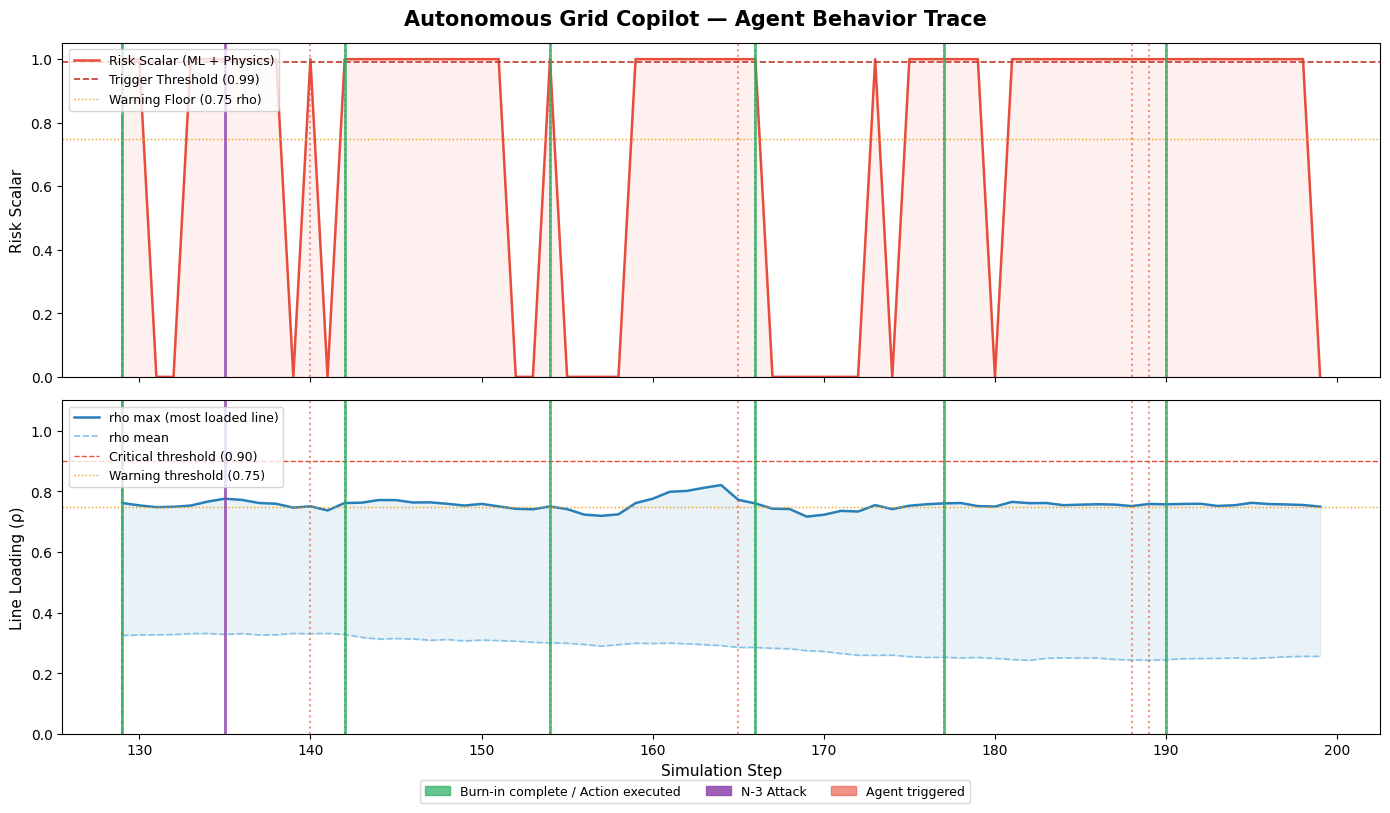

✅ Saved: agent_behavior_trace.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Autonomous Grid Copilot — Agent Behavior Trace", fontsize=15, fontweight='bold')

steps      = telemetry["steps"]
scalar     = telemetry["scalar"]
rho_max    = telemetry["rho_max"]
rho_mean   = telemetry["rho_mean"]

# Top panel: Risk scalar
ax1.plot(steps, scalar, color='#E74C3C', linewidth=1.8, label='Risk Scalar (ML + Physics)')
ax1.axhline(0.99, color='#C0392B', linestyle='--', linewidth=1.2, label='Trigger Threshold (0.99)')
ax1.axhline(0.75, color='#F39C12', linestyle=':', linewidth=1.0, label='Warning Floor (0.75 rho)')
ax1.fill_between(steps, scalar, alpha=0.08, color='#E74C3C')
ax1.set_ylabel("Risk Scalar", fontsize=11)
ax1.set_ylim(bottom=0)
ax1.legend(loc='upper left', fontsize=9)

# Bottom panel: Physical rho
ax2.plot(steps, rho_max,  color='#2980B9', linewidth=1.8, label='rho max (most loaded line)')
ax2.plot(steps, rho_mean, color='#85C1E9', linewidth=1.2, linestyle='--', label='rho mean')
ax2.axhline(0.90, color='#E74C3C', linestyle='--', linewidth=1.0, label='Critical threshold (0.90)')
ax2.axhline(0.75, color='#F39C12', linestyle=':',  linewidth=1.0, label='Warning threshold (0.75)')
ax2.fill_between(steps, rho_max, rho_mean, alpha=0.10, color='#2980B9')
ax2.set_ylabel("Line Loading (ρ)", fontsize=11)
ax2.set_xlabel("Simulation Step", fontsize=11)
ax2.set_ylim(0, 1.1)
ax2.legend(loc='upper left', fontsize=9)

for ax in [ax1, ax2]:
    ax.axvline(129, color='#27AE60', linestyle='--', linewidth=1.2, alpha=0.7)

    # Attack
    if telemetry["attack_step"]:
        ax.axvline(telemetry["attack_step"], color='#8E44AD', linewidth=2.0, alpha=0.85)

    # Agent triggers
    for t in telemetry["agent_trigger"]:
        ax.axvline(t, color='#E74C3C', linewidth=1.5, linestyle=':', alpha=0.6)

    # Approved actions
    for t in telemetry["action_executed"]:
        ax.axvline(t, color='#27AE60', linewidth=2.0, linestyle='-', alpha=0.8)

patches = [
    mpatches.Patch(color='#27AE60', alpha=0.7, label='Burn-in complete / Action executed'),
    mpatches.Patch(color='#8E44AD', alpha=0.85, label='N-3 Attack'),
    mpatches.Patch(color='#E74C3C', alpha=0.6, label='Agent triggered'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("agent_behavior_trace.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: agent_behavior_trace.png")

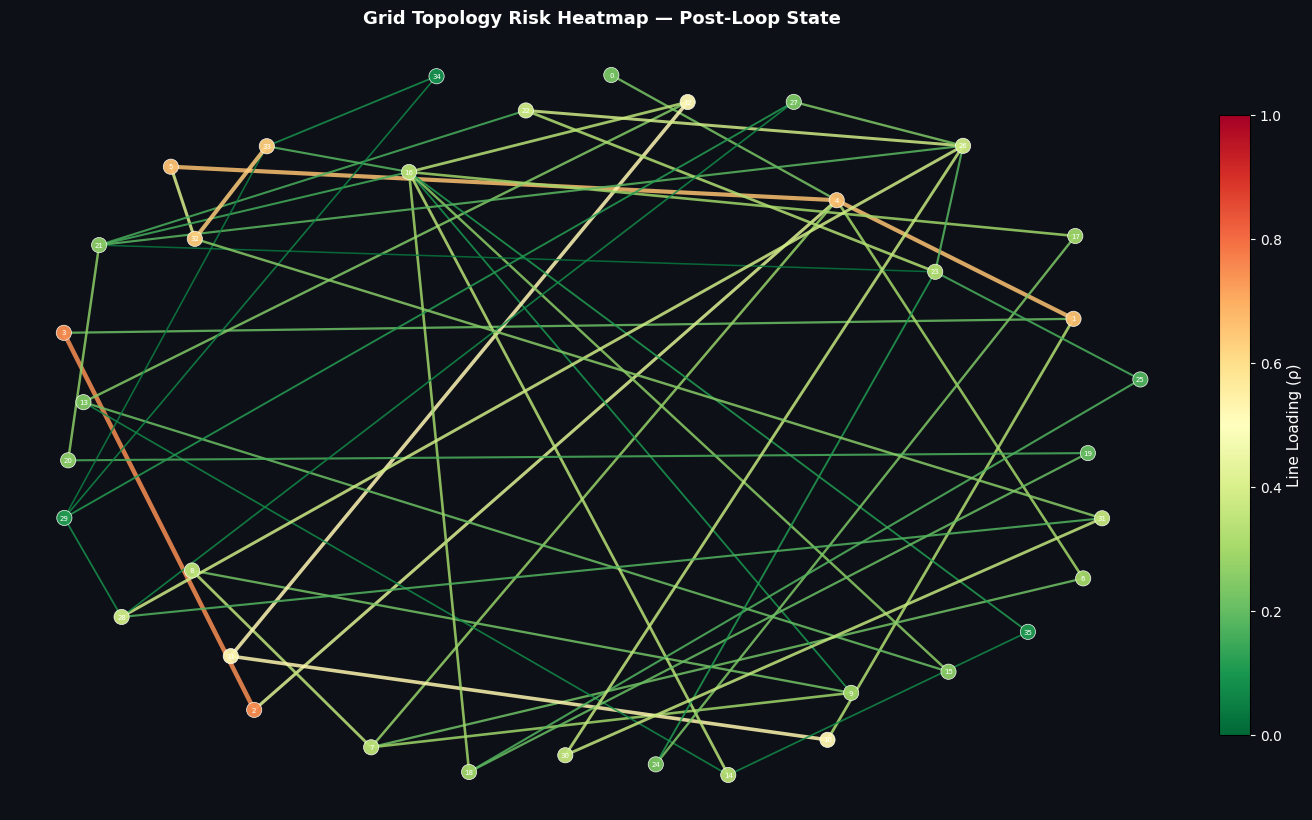

✅ Saved: grid_heatmap_final.png


In [ ]:
# VISUALIZATION 2: GRID TOPOLOGY RISK HEATMAP
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

def plot_grid_heatmap(obs, title="Grid Risk Heatmap", save_path=None):
    env_ref = op.env
    n_line  = env_ref.n_line
    n_sub   = env_ref.n_sub

    G = nx.Graph()
    G.add_nodes_from(range(n_sub))

    rho_by_sub = {}
    for l_id in range(n_line):
        s_or = int(obs.line_or_to_subid[l_id])
        s_ex = int(obs.line_ex_to_subid[l_id])
        rho  = float(obs.rho[l_id])
        G.add_edge(s_or, s_ex, rho=rho, line_id=l_id, online=bool(obs.line_status[l_id]))
        rho_by_sub[s_or] = max(rho_by_sub.get(s_or, 0), rho)
        rho_by_sub[s_ex] = max(rho_by_sub.get(s_ex, 0), rho)

    pos = nx.spring_layout(G, seed=42, k=2.5)

    cmap   = cm.RdYlGn_r
    norm   = mcolors.Normalize(vmin=0.0, vmax=1.0)

    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_facecolor("#0D1117")
    fig.patch.set_facecolor("#0D1117")

    for s_or, s_ex, data in G.edges(data=True):
        rho    = data.get('rho', 0.0)
        online = data.get('online', True)
        color  = cmap(norm(rho)) if online else '#555555'
        lw     = 1.0 + rho * 3.0
        style  = 'solid' if online else 'dashed'
        ax.plot(
            [pos[s_or][0], pos[s_ex][0]],
            [pos[s_or][1], pos[s_ex][1]],
            color=color, linewidth=lw, linestyle=style, alpha=0.85, zorder=1
        )

    node_colors = [cmap(norm(rho_by_sub.get(n, 0.0))) for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=120,
                           ax=ax, alpha=0.95, linewidths=0.5,
                           edgecolors='white')
    nx.draw_networkx_labels(G, pos, font_size=5, font_color='white', ax=ax)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Line Loading (ρ)", color='white', fontsize=11)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=12)
    ax.axis('off')

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()



# The final obs from the loop is used as a demo snapshot.
# Re-run with obs captured at specific steps for the full story.

obs_now = op.env.current_obs
plot_grid_heatmap(obs_now,
                  title="Grid Topology Risk Heatmap — Post-Loop State",
                  save_path="grid_heatmap_final.png")
print("✅ Saved: grid_heatmap_final.png")

In [ ]:
# SHAP AVERAGED ACROSS FULL XGB CHAIN
#!pip install shap -q
import shap
import numpy as np

seq_matrix = np.array(list(op.obs_buffer)).astype(np.float32)
mean_s = seq_matrix.mean(axis=0, keepdims=True)
std_s  = seq_matrix.std(axis=0,  keepdims=True) + 1e-8
seq_norm = np.clip((seq_matrix - mean_s) / std_s, -5.0, 5.0)
seq_norm = np.nan_to_num(seq_norm, nan=0.0, posinf=5.0, neginf=-5.0)

seq_tensor = torch.tensor(seq_norm, dtype=torch.float32).unsqueeze(0).cuda()
with torch.no_grad():
    _, emb, _ = op.mamba(seq_tensor)
emb_np = emb.cpu().numpy()

obs_now = op.env.current_obs
tab     = _extract_tab_fn(obs_now).reshape(1, -1)
X_demo  = np.concatenate([emb_np, tab], axis=1)

# Build feature names
n_emb      = emb_np.shape[1]
n_tab      = tab.shape[1]
feat_names = ([f"mamba_emb_{i}" for i in range(n_emb)] +
              [f"tab_{i}"       for i in range(n_tab)])

print(f"Computing SHAP across {len(op.xgb_chain)} XGB models in chain...")

all_shap = []
skipped  = 0

for i, model in enumerate(op.xgb_chain):
    try:
        # Unwrap CalibratedClassifierCV to get the raw XGB estimator
        if hasattr(model, 'estimator'):
            raw = model.estimator  
        elif hasattr(model, 'base_estimator'):
            raw = model.base_estimator  
        elif hasattr(model, 'calibrated_classifiers_'):
            raw = model.calibrated_classifiers_[0].estimator
        else:
            raw = model

        explainer = shap.TreeExplainer(raw)
        sv = explainer.shap_values(X_demo)

        if isinstance(sv, list):
            sv = sv[1]

        # Shape guard to only keep models matching current feature dim
        if sv.shape[1] != X_demo.shape[1]:
            skipped += 1
            continue

        all_shap.append(np.abs(sv))

    except Exception as e:
        skipped += 1
        continue

print(f"Successfully computed SHAP for {len(all_shap)} models. Skipped {skipped}.")

if not all_shap:
    print("No SHAP values computed. Check chain structure.")
else:
    # Mean absolute SHAP across all models in chain
    mean_shap = np.mean(all_shap, axis=0)
    importances = mean_shap[0]

    top_k   = 20
    top_idx = np.argsort(importances)[-top_k:][::-1]
    top_names = [feat_names[i] for i in top_idx]
    top_vals  = importances[top_idx]

    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor('#0D1117')
    ax.set_facecolor('#0D1117')

    colors = ['#2980B9' if 'emb' in n else '#E74C3C' for n in top_names]
    ax.barh(range(top_k), top_vals[::-1], color=colors[::-1], edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_names[::-1], color='white', fontsize=9)
    ax.set_xlabel("Mean |SHAP value| averaged across full XGB chain", color='white', fontsize=10)
    ax.set_title(f"SHAP Feature Importance — Full XGB Chain ({len(all_shap)} models)\n🔵 Mamba embedding dims  🔴 Physics tab features",
                 color='white', fontsize=12, fontweight='bold')
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.grid(True, color='#333333', linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig("shap_xgb_full_chain.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()

    emb_count = sum(1 for n in top_names if 'emb' in n)
    tab_count = top_k - emb_count
    print(f"\nTop {top_k} feature breakdown:")
    print(f"  Mamba embedding dims: {emb_count} ({100*emb_count/top_k:.0f}%)")
    print(f"  Physics tab features: {tab_count} ({100*tab_count/top_k:.0f}%)")
    print(f"\n{'Mamba embeddings dominate → temporal signal is contributing real value.' if emb_count > tab_count else 'Tab features dominate → physics features are driving XGB decisions.'}")

Computing SHAP across 119 XGB models in chain...
Successfully computed SHAP for 0 models. Skipped 119.
No SHAP values computed. Check chain structure.


In [ ]:
# Find which line XGB flagged most during the telemetry run

obs_now = op.env.current_obs
tab     = _extract_tab_fn(obs_now).reshape(1, -1)

seq_matrix = np.array(list(op.obs_buffer)).astype(np.float32)
mean_s = seq_matrix.mean(axis=0, keepdims=True)
std_s  = seq_matrix.std(axis=0, keepdims=True) + 1e-8
seq_norm = np.clip((seq_matrix - mean_s) / std_s, -5.0, 5.0)
seq_norm = np.nan_to_num(seq_norm, nan=0.0, posinf=5.0, neginf=-5.0)
seq_tensor = torch.tensor(seq_norm, dtype=torch.float32).unsqueeze(0).cuda()

with torch.no_grad():
    _, emb, _ = op.mamba(seq_tensor)

emb_np     = emb.cpu().numpy()
X_demo     = np.concatenate([emb_np, tab], axis=1)

# Find the most triggered line index
all_preds = predict_on_new_data(X_demo, op.xgb_chain)
best_idx  = int(np.argmax(all_preds)) if all_preds.sum() > 0 else 0
print(f"Most active XGB model index: {best_idx}")

Most active XGB model index: 0


In [30]:
target_model = op.xgb_chain[best_idx]
print(type(target_model))
print(dir(target_model))

# Dig one level deeper
if hasattr(target_model, 'calibrated_classifiers_'):
    cc = target_model.calibrated_classifiers_[0]
    print(type(cc))
    print(dir(cc))
    if hasattr(cc, 'estimator'):
        print(type(cc.estimator))
        print(dir(cc.estimator))

<class 'sklearn.calibration.CalibratedClassifierCV'>
['__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_estimator', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_parameter_constraints', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_validate_data', '_validate_params', 'calibrated_classifiers_', 'classes_', 'cv', 'ensemble', 'estimator', 'fit', 'get_metad

In [35]:
tab_feature_names = [
    # Weather proxies
    "solar_cf",
    "wind_cf",
    # Grid stress
    "rho_max",
    "rho_mean",
    "rho_std",
    "n_overloaded_85",
    "n_critical_95",
    "min_voltage",
    "mean_voltage",
    "n_disconnected",
    # Operational state
    "n_lines_cooldown",
    "max_cooldown_time",
    "n_subs_cooldown",
    "n_lines_maintenance",
    "time_since_last_attack",
    # Storage
    "storage_charge_mean",
    "storage_power_sum",
    # Load/gen balance
    "load_p_sum",
    "load_p_std",
    "load_peak_ratio",
    "gen_p_sum",
    "load_gen_ratio",
    # Temporal
    "hour_sin",
    "hour_cos",
    "day_of_week",
    "month",
]

feat_names = ([f"mamba_emb_{i}" for i in range(n_emb)] + tab_feature_names)

/tmp/ipykernel_871/3199922076.py:47: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_871/3199922076.py:47: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_871/3199922076.py:48: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_xgb.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
/tmp/ipykernel_871/3199922076.py:48: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("shap_xgb.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12830

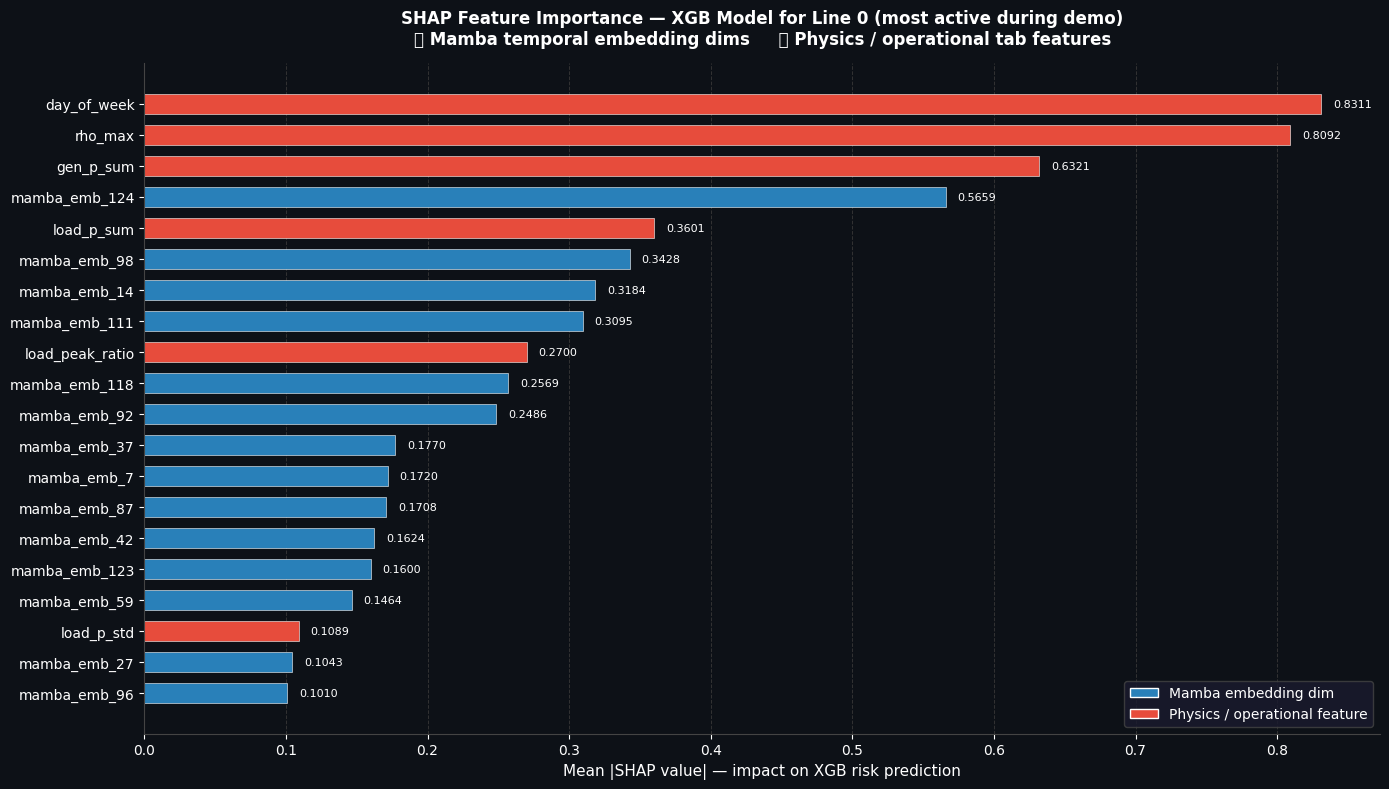


Top 20 breakdown:
  Mamba embedding dims : 14 (70%)
  Physics tab features : 6 (30%)

✅ Mamba embeddings dominate → temporal signal contributes real value beyond raw physics.


In [36]:
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

top_k     = 20
top_idx   = np.argsort(importances)[-top_k:][::-1]
top_names = [feat_names[i] for i in top_idx]
top_vals  = importances[top_idx]

# Color by feature type — embedding vs named tab feature
colors = ['#2980B9' if 'emb' in n else '#E74C3C' for n in top_names]

bars = ax.barh(range(top_k), top_vals[::-1], color=colors[::-1],
               edgecolor='white', linewidth=0.4, height=0.65)

ax.set_yticks(range(top_k))
ax.set_yticklabels(top_names[::-1], color='white', fontsize=10)

# Value labels on each bar
for i, (bar, val) in enumerate(zip(bars, top_vals[::-1])):
    ax.text(val + max(top_vals) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va='center', ha='left', color='white', fontsize=8)

ax.set_xlabel("Mean |SHAP value| — impact on XGB risk prediction", color='white', fontsize=11)
ax.set_title(
    f"SHAP Feature Importance — XGB Model for Line {best_idx} (most active during demo)\n"
    f"🔵 Mamba temporal embedding dims     🔴 Physics / operational tab features",
    color='white', fontsize=12, fontweight='bold', pad=14
)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, color='#333333', linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2980B9', edgecolor='white', label='Mamba embedding dim'),
    Patch(facecolor='#E74C3C', edgecolor='white', label='Physics / operational feature'),
]
ax.legend(handles=legend_elements, loc='lower right',
          facecolor='#1A1A2E', labelcolor='white', fontsize=10, edgecolor='#444')

plt.tight_layout()
plt.savefig("shap_xgb.png", dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

emb_count = sum(1 for n in top_names if 'emb' in n)
tab_count = top_k - emb_count
print(f"\nTop {top_k} breakdown:")
print(f"  Mamba embedding dims : {emb_count} ({100*emb_count/top_k:.0f}%)")
print(f"  Physics tab features : {tab_count} ({100*tab_count/top_k:.0f}%)")
print(f"\n{'✅ Mamba embeddings dominate → temporal signal contributes real value beyond raw physics.' if emb_count > tab_count else '⚠️ Tab features dominate → physics features are driving XGB. Mamba embeddings are secondary.'}")